## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
augmentation = False
augmentation_weights = [0.9, 0.1]
proportion_of_augmented = 0.25

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) przedziały ufności

## Loading the data

In [3]:
data_path = '../data/DANE.xlsx'
figures_path = '../results/visualisations/'

In [4]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [5]:
inks_df = inks_df.reset_index(drop=False)

In [6]:
inds_df = inds_df.reset_index(drop=False)

In [7]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [8]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [9]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

### Removing some data

1. Let's remove rows with missing values.

In [10]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [11]:
inDKs_df.dropna(inplace=True)

2. Let's keep only columns that we need.

In [12]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

If you want to keep use version with 29 numbers, just comment out the cell below.

In [13]:
inks_colnames = [
 'Al_inks',
 'S_inks',
 'Cr_inks',
 'Mn_inks',
 'Co_inks',
 'Cu_inks',
 'Zn_inks',
 'Pb_inks']

inds_colnames = [
 'Al_inds',
 'S_inds',
 'Cr_inds',
 'Mn_inds',
 'Co_inds',
 'Cu_inds',
 'Zn_inds',
 'Pb_inds']

In [14]:
inDKs_df = inDKs_df[inks_colnames + inds_colnames + ['Sample_id']]

### Train test split, datasets, dataloaders

In [15]:
if keep_sample_together:
    indices = list(range(inDKs_df['Sample_id'].max()))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

In [16]:
# if augmentation:
#     X_train = torch.cat([X_train, X_aug])
#     y_train = torch.cat([y_train, y_aug])

### Data augmentation

In [17]:
if real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [18]:
if real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))
    
    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']
    
    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [19]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']
if augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[inds_colnames].values)
y_train = np.array(X_y_train[inks_colnames].values)
X_val = np.array(X_y_val[inds_colnames].values)
y_val = np.array(X_y_val[inks_colnames].values)
X_test = np.array(X_y_test[inds_colnames].values)
y_test = np.array(X_y_test[inks_colnames].values)
if augmentation:
    X_augmented = np.array(X_y_augmented[inds_colnames].values)
    y_augmented = np.array(X_y_augmented[inks_colnames].values)

### Normalization

In [20]:
if augmentation:
    X_all = np.concatenate([X_train, X_augmented])
    y_all = np.concatenate([y_train, y_augmented])
    
    X_all = (X_all - np.mean(X_all, axis=0))/np.std(X_all, axis=0)
    y_all = (y_all - np.mean(y_all, axis=0))/np.std(y_all, axis=0)
        
    X_train = X_all[:X_train.shape[0],:]
    X_augmented = X_all[X_train.shape[0]:,:]
    y_train = y_all[:y_train.shape[0],:]
    y_augmented = y_all[y_train.shape[0]:,:]
else:
    X_train = (X_train - np.mean(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.mean(y_train, axis=0))/np.std(y_train, axis=0)
    
X_val = (X_val - np.mean(X_val, axis=0))/np.std(X_val, axis=0)
y_val = (y_val - np.mean(y_val, axis=0))/np.std(y_val, axis=0)

X_test = (X_test - np.mean(X_test, axis=0))/np.std(X_test, axis=0)
y_test = (y_test - np.mean(y_test, axis=0))/np.std(y_test, axis=0)

### Converting to tensors

In [21]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [22]:
if augmentation:
    X_train = torch.Tensor(np.concatenate([X_train, X_augmented])).to(device)
    y_train = torch.Tensor(np.concatenate([y_train, y_augmented])).to(device)
else:
    X_train = torch.Tensor(X_train).to(device)
    y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [23]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [24]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [25]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [26]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [27]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [28]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
  )
)


In [29]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

1/2, 1/4, 1/8, 1/40, 1/40, 1/40, 1/40, 1/40

1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40


In [30]:
#weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/3,1/3,1/18,1/18,1/18,1/18,1/18,1/18]).unsqueeze(1).to(device)
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)
#weights = torch.tensor([1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20]).unsqueeze(1).to(device)


class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [31]:
# loss = F.l1_loss(torch.t(torch.mul(torch.t(forecast), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))) ,
#                          torch.t(torch.mul(torch.t(torch.tensor(target,dtype=torch.float).to(DEVICE)), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))),reduction='mean')
# loss.backward()
# params.append(net.parameters())
# optimiser.step()

In [32]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 0.38542512655258176 test 0.40430841007217855
EPOCH 2:
LOSS train 0.3809468328952789 test 0.4019153120910159
EPOCH 3:
LOSS train 0.38323741356531776 test 0.3995667077431274
EPOCH 4:
LOSS train 0.37772584954897565 test 0.3972737007382987
EPOCH 5:
LOSS train 0.3751152753829956 test 0.39502629242822
EPOCH 6:
LOSS train 0.3727495531241099 test 0.392835747874795
EPOCH 7:
LOSS train 0.36706705490748087 test 0.39068058574298403
EPOCH 8:
LOSS train 0.3642995496590932 test 0.38856999640879425
EPOCH 9:
LOSS train 0.3624888916810354 test 0.3864802258170169
EPOCH 10:
LOSS train 0.3642958203951518 test 0.38446288153251507
EPOCH 11:
LOSS train 0.36167808969815574 test 0.38250737722122397
EPOCH 12:
LOSS train 0.35754119157791137 test 0.38062944767638024
EPOCH 13:
LOSS train 0.3540619651476542 test 0.37881914123615124
EPOCH 14:
LOSS train 0.3524482548236847 test 0.37706112759824123
EPOCH 15:
LOSS train 0.3538635432720184 test 0.3753568853403964
EPOCH 16:
LOSS train 0.355025831858317

LOSS train 0.2002417266368866 test 0.21804738218084316
EPOCH 128:
LOSS train 0.2027702902754148 test 0.2179918680012257
EPOCH 129:
LOSS train 0.20087334463993708 test 0.217898306571811
EPOCH 130:
LOSS train 0.19877319435278576 test 0.217822000216577
EPOCH 131:
LOSS train 0.2008463203907013 test 0.21774566307949292
EPOCH 132:
LOSS train 0.19636560529470443 test 0.21762044442620893
EPOCH 133:
LOSS train 0.20262157171964645 test 0.21761518270818528
EPOCH 134:
LOSS train 0.19845603108406068 test 0.2174481042982783
EPOCH 135:
LOSS train 0.19774058759212493 test 0.21745189326944497
EPOCH 136:
LOSS train 0.19746287167072296 test 0.21729662697222354
EPOCH 137:
LOSS train 0.19836717545986177 test 0.21725108022329168
EPOCH 138:
LOSS train 0.1964726373553276 test 0.21715994284721574
EPOCH 139:
LOSS train 0.2011180539925893 test 0.21708003777671242
EPOCH 140:
LOSS train 0.20196265677611033 test 0.21693432822584427
EPOCH 141:
LOSS train 0.19978881776332855 test 0.21691060841168366
EPOCH 142:
LOSS t

LOSS train 0.18981367746988934 test 0.2062500442491987
EPOCH 252:
LOSS train 0.18792063643534979 test 0.20607516307993087
EPOCH 253:
LOSS train 0.187875301639239 test 0.2060029596499096
EPOCH 254:
LOSS train 0.18720012803872427 test 0.20585224813324696
EPOCH 255:
LOSS train 0.1852378437916438 test 0.2058672832429224
EPOCH 256:
LOSS train 0.18889925678571065 test 0.20569297237472134
EPOCH 257:
LOSS train 0.1909405509630839 test 0.20566023280362042
EPOCH 258:
LOSS train 0.1883772869904836 test 0.20550962880747412
EPOCH 259:
LOSS train 0.18789672801891963 test 0.2054473305657105
EPOCH 260:
LOSS train 0.1856226623058319 test 0.20538330613780095
EPOCH 261:
LOSS train 0.1861440191666285 test 0.20525806937868057
EPOCH 262:
LOSS train 0.19040686388810477 test 0.2051709406579195
EPOCH 263:
LOSS train 0.18669832994540533 test 0.20504758604194806
EPOCH 264:
LOSS train 0.18774653772513072 test 0.20500340104858944
EPOCH 265:
LOSS train 0.18797534008820851 test 0.20488661126952856
EPOCH 266:
LOSS tr

LOSS train 0.17742662529150646 test 0.19527741254347822
EPOCH 376:
LOSS train 0.1778351217508316 test 0.1952263467808256
EPOCH 377:
LOSS train 0.179486978550752 test 0.19507378514462748
EPOCH 378:
LOSS train 0.17527727484703065 test 0.19492511918255384
EPOCH 379:
LOSS train 0.17620832920074464 test 0.1949652369764651
EPOCH 380:
LOSS train 0.18029732257127762 test 0.19485500240100714
EPOCH 381:
LOSS train 0.18290910025437673 test 0.19461051098555018
EPOCH 382:
LOSS train 0.17832213193178176 test 0.1945723855894977
EPOCH 383:
LOSS train 0.17595327297846478 test 0.19456487501861516
EPOCH 384:
LOSS train 0.17785471826791763 test 0.19445162558422943
EPOCH 385:
LOSS train 0.17697019775708517 test 0.1941770921204833
EPOCH 386:
LOSS train 0.17938510775566102 test 0.19428317344845822
EPOCH 387:
LOSS train 0.1758871629834175 test 0.19418239974518986
EPOCH 388:
LOSS train 0.17754297951857248 test 0.19395230752541287
EPOCH 389:
LOSS train 0.17560652593771617 test 0.19396932040173445
EPOCH 390:
LOS

LOSS train 0.1655192643404007 test 0.1813954940956572
EPOCH 500:
LOSS train 0.168968732158343 test 0.18133952546918738
EPOCH 501:
LOSS train 0.16448510934909186 test 0.1813522138889285
EPOCH 502:
LOSS train 0.1725928619503975 test 0.18113885003124705
EPOCH 503:
LOSS train 0.16910856713851294 test 0.18109498527787982
EPOCH 504:
LOSS train 0.168741641441981 test 0.1809920679014292
EPOCH 505:
LOSS train 0.16459277917941412 test 0.18088195048365163
EPOCH 506:
LOSS train 0.1678289343913396 test 0.1807391396906867
EPOCH 507:
LOSS train 0.16361581136782963 test 0.18071370130678635
EPOCH 508:
LOSS train 0.16653282344341278 test 0.18069632694618795
EPOCH 509:
LOSS train 0.16636683295170465 test 0.18049053414329486
EPOCH 510:
LOSS train 0.16572282016277312 test 0.1804482984582182
EPOCH 511:
LOSS train 0.16262291272481283 test 0.18036540070506232
EPOCH 512:
LOSS train 0.1699152539173762 test 0.18038262171558958
EPOCH 513:
LOSS train 0.16693460792303086 test 0.1802195155719299
EPOCH 514:
LOSS trai

...

LOSS train 0.13127129624287287 test 0.14568012419656134
EPOCH 4420:
LOSS train 0.1346719577908516 test 0.1456554154605136
EPOCH 4421:
LOSS train 0.13012125144402187 test 0.14561126102147698
EPOCH 4422:
LOSS train 0.1304366593559583 test 0.14574408435742864
EPOCH 4423:
LOSS train 0.13190448954701423 test 0.14564609813347737
EPOCH 4424:
LOSS train 0.13243214190006256 test 0.14562389543800622
EPOCH 4425:
LOSS train 0.12953147565325102 test 0.1456223975280859
EPOCH 4426:
LOSS train 0.13098029990990956 test 0.14576778938612028
EPOCH 4427:
LOSS train 0.13125425477822622 test 0.14562861435886618
EPOCH 4428:
LOSS train 0.13332749009132386 test 0.14576197373555438
EPOCH 4429:
LOSS train 0.13358742346366245 test 0.14562259639341454
EPOCH 4430:
LOSS train 0.13444951424996057 test 0.14563141087760403
EPOCH 4431:
LOSS train 0.13382857541243234 test 0.1456759030762944
EPOCH 4432:
LOSS train 0.13314174314339955 test 0.14568425007318733
EPOCH 4433:
LOSS train 0.1304321552316348 test 0.1457199727938998

LOSS train 0.13018891712029776 test 0.14545197752314015
EPOCH 4542:
LOSS train 0.13309752742449443 test 0.14546479708004134
EPOCH 4543:
LOSS train 0.13573474089304607 test 0.1454777991645979
EPOCH 4544:
LOSS train 0.13803251286347706 test 0.14535929261866812
EPOCH 4545:
LOSS train 0.13323899060487748 test 0.14549581466269665
EPOCH 4546:
LOSS train 0.13087253123521805 test 0.14537568889967095
EPOCH 4547:
LOSS train 0.1315498724579811 test 0.14553240459512604
EPOCH 4548:
LOSS train 0.1297145813703537 test 0.14544917871562404
EPOCH 4549:
LOSS train 0.1334730972846349 test 0.14548226037519688
EPOCH 4550:
LOSS train 0.13001891275246938 test 0.14550045322950766
EPOCH 4551:
LOSS train 0.1319852073987325 test 0.14548032174338094
EPOCH 4552:
LOSS train 0.13294068475564322 test 0.14545107734877438
EPOCH 4553:
LOSS train 0.1319261665145556 test 0.14552942229778068
EPOCH 4554:
LOSS train 0.13279586285352707 test 0.1454422342828157
EPOCH 4555:
LOSS train 0.1314345344901085 test 0.1454107590389918
E

LOSS train 0.1354053924481074 test 0.14530518150254004
EPOCH 4664:
LOSS train 0.1316793108979861 test 0.14528487141458143
EPOCH 4665:
LOSS train 0.12937932113806408 test 0.14537865102992972
EPOCH 4666:
LOSS train 0.13258879631757736 test 0.14527008437221836
EPOCH 4667:
LOSS train 0.12993687242269517 test 0.14527167303113586
EPOCH 4668:
LOSS train 0.1303891842563947 test 0.1452901693153548
EPOCH 4669:
LOSS train 0.13025875886281332 test 0.14524421145017288
EPOCH 4670:
LOSS train 0.13354428956906 test 0.14527062963555504
EPOCH 4671:
LOSS train 0.12953698883454004 test 0.14535568298590726
EPOCH 4672:
LOSS train 0.1303009122610092 test 0.1452213287368941
EPOCH 4673:
LOSS train 0.1346164584159851 test 0.1452404342661178
EPOCH 4674:
LOSS train 0.1317127635081609 test 0.14532054627148383
EPOCH 4675:
LOSS train 0.1313376545906067 test 0.14531990715088497
EPOCH 4676:
LOSS train 0.1343756025036176 test 0.14529761777685543
EPOCH 4677:
LOSS train 0.13164336731036505 test 0.14523231987619684
EPOCH 

LOSS train 0.130062273144722 test 0.14509296379057887
EPOCH 4786:
LOSS train 0.13095769385496775 test 0.14512161243953753
EPOCH 4787:
LOSS train 0.12978417923053107 test 0.14500982995389905
EPOCH 4788:
LOSS train 0.13307055234909057 test 0.14519007532523778
EPOCH 4789:
LOSS train 0.12951007535060247 test 0.14505671338403817
EPOCH 4790:
LOSS train 0.12954116264979046 test 0.14514456137505746
EPOCH 4791:
LOSS train 0.1305100440979004 test 0.14507913793867172
EPOCH 4792:
LOSS train 0.13241514712572097 test 0.14506541932961955
EPOCH 4793:
LOSS train 0.13310504804054896 test 0.14519385456475845
EPOCH 4794:
LOSS train 0.13294283201297125 test 0.14502601345179614
EPOCH 4795:
LOSS train 0.12986015876134235 test 0.14511728925749998
EPOCH 4796:
LOSS train 0.13121706495682398 test 0.1451439257483644
EPOCH 4797:
LOSS train 0.13340587963660558 test 0.14513693297933594
EPOCH 4798:
LOSS train 0.13023106902837753 test 0.1450182013888506
EPOCH 4799:
LOSS train 0.1308727006117503 test 0.1451195437349302

LOSS train 0.12997901290655137 test 0.14489385148406214
EPOCH 4908:
LOSS train 0.1292101244131724 test 0.14487027434350663
EPOCH 4909:
LOSS train 0.13390323321024578 test 0.14503543248581344
EPOCH 4910:
LOSS train 0.13209023475646972 test 0.14503727050008364
EPOCH 4911:
LOSS train 0.13525713632504147 test 0.1449981858494921
EPOCH 4912:
LOSS train 0.13226845363775888 test 0.14492176028304032
EPOCH 4913:
LOSS train 0.12968700677156447 test 0.14492164684100922
EPOCH 4914:
LOSS train 0.13252301762501398 test 0.14503290628971952
EPOCH 4915:
LOSS train 0.13239948252836864 test 0.14502820802570993
EPOCH 4916:
LOSS train 0.12921441048383714 test 0.14497442431285146
EPOCH 4917:
LOSS train 0.13111605842908222 test 0.14498497135204497
EPOCH 4918:
LOSS train 0.13349833637475966 test 0.14488786803924827
EPOCH 4919:
LOSS train 0.13329670826594034 test 0.14496167327275433
EPOCH 4920:
LOSS train 0.132583353916804 test 0.14505308423013913
EPOCH 4921:
LOSS train 0.13560036569833755 test 0.14483496423725

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

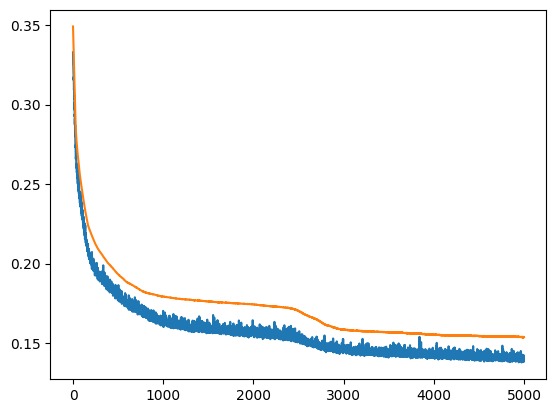

In [34]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights 1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

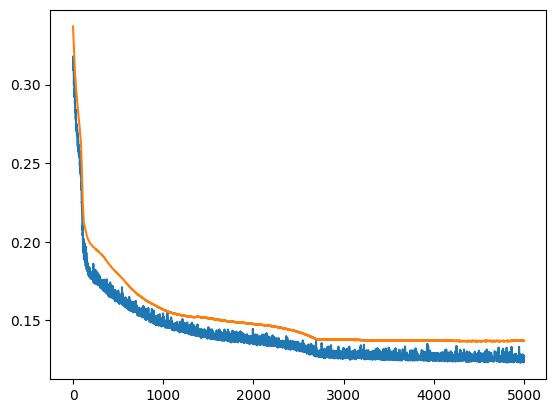

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/8, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

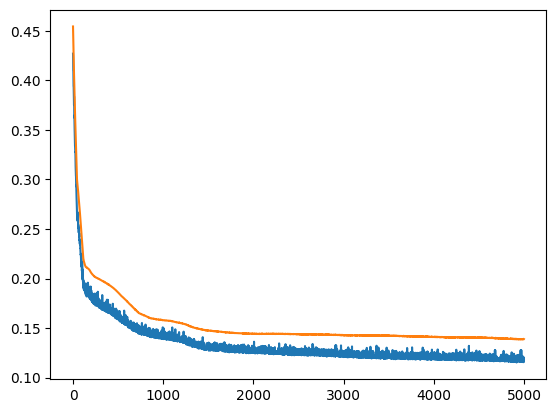

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

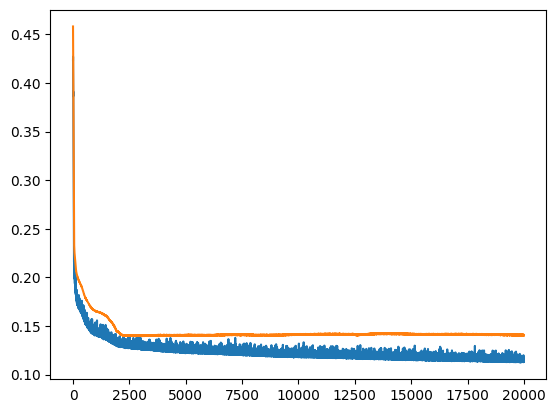

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

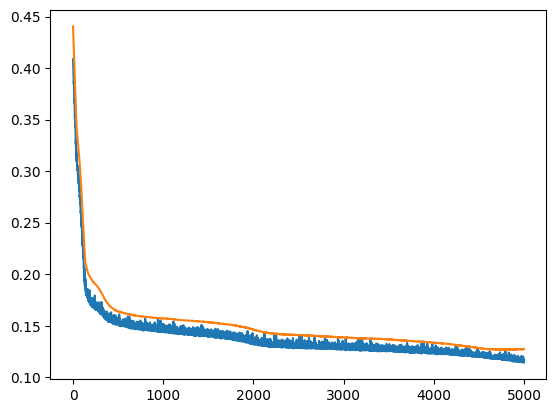

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#6 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#6 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#8 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#6 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/3, 1/3, 1/18, 1/18, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/8, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#Augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#Augmentation
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#Augmentation
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 8 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

In [ ]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Test set

In [34]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [35]:
lab

tensor([[-0.1708, -0.1462, -0.1736,  ..., -0.0608, -0.0793, -0.0689],
        [-0.3054, -0.1553, -0.1758,  ..., -0.0609, -0.2114, -0.0837],
        [-0.2513, -0.0670, -0.1743,  ..., -0.0609, -0.1948, -0.0663],
        ...,
        [-0.1755, -0.1445, -0.1757,  ..., -0.0609, -0.2052, -0.0352],
        [-0.2485, -0.1530, -0.1758,  ..., -0.0562, -0.2033, -0.0837],
        [-0.2552, -0.1244, -0.1750,  ..., -0.0607, -0.2118, -0.0631]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [36]:
out

tensor([[-0.2677, -0.1122, -0.1727,  ..., -0.0689, -0.1907, -0.0956],
        [-0.2788, -0.1028, -0.1763,  ..., -0.0689, -0.2174, -0.0961],
        [-0.2416, -0.1450, -0.1860,  ..., -0.0689, -0.1960, -0.0935],
        ...,
        [-0.2129, -0.1328, -0.1806,  ..., -0.0689, -0.1828, -0.0920],
        [-0.2594, -0.1616, -0.1920,  ..., -0.0689, -0.2058, -0.0956],
        [-0.2875, -0.1179, -0.1861,  ..., -0.0689, -0.2123, -0.0960]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [37]:
res

tensor([[0.0969, 0.0341, 0.0009,  ..., 0.0081, 0.1114, 0.0267],
        [0.0265, 0.0526, 0.0005,  ..., 0.0080, 0.0060, 0.0123],
        [0.0097, 0.0780, 0.0117,  ..., 0.0080, 0.0013, 0.0272],
        ...,
        [0.0374, 0.0117, 0.0048,  ..., 0.0079, 0.0224, 0.0568],
        [0.0109, 0.0086, 0.0163,  ..., 0.0127, 0.0025, 0.0118],
        [0.0324, 0.0065, 0.0111,  ..., 0.0082, 0.0006, 0.0329]],
       device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [38]:
torch.mean(res, axis=0) 

tensor([0.1616, 0.1298, 0.1217, 0.2711, 0.2641, 0.0688, 0.1172, 0.0927],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [ ]:
Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [40]:
torch.mean(res)

tensor(0.1534, device='cuda:0', grad_fn=<MeanBackward0>)

Below: some experiments, visualisations...

In [42]:
dim_nr = 5
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

In [43]:
#torch.max(out, axis=0)

(-0.1, 0.1)

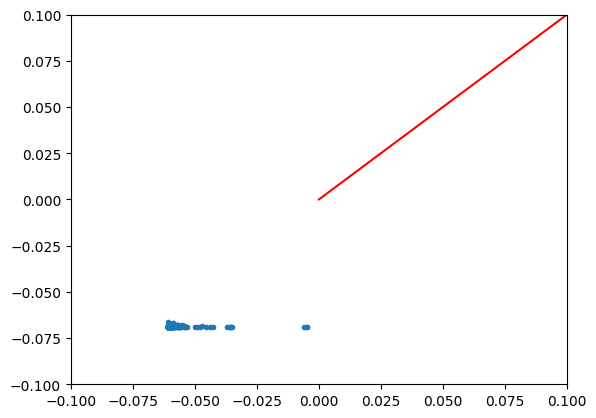

In [44]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [0,20],[0,20], 'red' )
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)

In [45]:
torch.mean(res, 0)

tensor([0.1616, 0.1298, 0.1217, 0.2711, 0.2641, 0.0688, 0.1172, 0.0927],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [46]:
mean_loss

0.15336497481256786

## Quality of prediction: closest points

#### First: sanity check - see if for real values of y_test closest classes means are the same as actually classes

In [47]:
elements_names = [el.split('_')[0] for el in inds_colnames]

In [48]:
y_test_normalized_df = pd.DataFrame(y_test.cpu())
y_test_normalized_df.columns = elements_names
y_test_normalized_df.insert(0, 'Sample_id', test_order)
y_test_normalized_df.reset_index(drop=True, inplace=True)

In [49]:
train_val_data_normalized_df = pd.DataFrame(y_train.cpu())
train_val_data_normalized_df = pd.concat([train_val_data_normalized_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_data_normalized_df.columns = elements_names
train_val_data_normalized_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_data_normalized_df.reset_index(drop=True, inplace=True)

In [50]:
mean_df = train_val_data_normalized_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_data_normalized_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
# for name in elements_names:
#     mean_sd_df[name + '_sd'] = train_val_data_normalized_df.groupby('Sample_id')[name].transform(np.std)
#     mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_6766/1554198251.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_data_normalized_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_6766/1554198251.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_6766/1554198251.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [51]:
closest = []
for i in range(y_test_normalized_df.shape[0]):
    closest.append((abs(y_test_normalized_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin())

In [52]:
len(closest)

483

In [53]:
y_test_normalized_df['Closest'] = closest

In [54]:
y_test_normalized_df[y_test_normalized_df['Sample_id'] == y_test_normalized_df['Closest']].shape[0]

240

In [55]:
240/483

0.4968944099378882

#### And now the same check for predicted values instead of true y_test values

In [56]:
model.eval()
outputs = model(X_test)

In [61]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [62]:
closest = []
for i in range(outputs_df.shape[0]):
    closest.append((abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin())

In [63]:
len(closest)

483

In [64]:
y_test_normalized_df['Closest'] = closest

In [65]:
y_test_normalized_df[y_test_normalized_df['Sample_id'] == y_test_normalized_df['Closest']].shape[0]

32

In [66]:
32/483

0.06625258799171843

## Quality of prediction: confidence intervals

In [67]:
model.eval()
outputs = model(X_test)

In [68]:
elements_names = [el.split('_')[0] for el in inds_colnames]

In [69]:
all_data_normalized_df = pd.DataFrame(y_train.cpu())
all_data_normalized_df = pd.concat([all_data_normalized_df, 
                                    pd.DataFrame(y_val.cpu()), 
                                    pd.DataFrame(y_test.cpu())])
all_data_normalized_df.columns = elements_names
all_data_normalized_df.insert(0, 'Sample_id', pd.concat([train_order, val_order, test_order]))
all_data_normalized_df.reset_index(drop=True, inplace=True)

In [70]:
min_max_df = all_data_normalized_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_normalized_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_normalized_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
min_df = min_max_df.iloc[:,1+len(elements_names):]

/tmp/ipykernel_6766/3971913909.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_normalized_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_6766/3971913909.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_6766/3971913909.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [71]:
mean_sd_df = all_data_normalized_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_normalized_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_normalized_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)

/tmp/ipykernel_6766/104805948.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_normalized_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_6766/104805948.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_6766/104805948.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

In [72]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > np.array(min_df.iloc[sample_id,:])
    
    less_than_max = test_example.cpu().detach().numpy() < np.array(max_df.iloc[sample_id,:])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [73]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > np.array(lower_bound_df.iloc[sample_id,:])
    
    less = test_example.cpu().detach().numpy() < np.array(upper_bound_df.iloc[sample_id,:])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [74]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

In [75]:
np.array(sd_res_list).mean()

0.6097308488612836

In [76]:
np.array(sd_res_list).mean(0)

array([0.53623188, 0.50310559, 0.35817805, 0.36231884, 0.78467909,
       0.98964803, 0.38923395, 0.95445135])

In [77]:
np.array(min_max_res_list).mean(0)

array([0.42857143, 0.45548654, 0.28571429, 0.29606625, 0.44513458,
       0.97515528, 0.3126294 , 0.77018634])

In [78]:
np.array(min_max_res_list).mean()

0.49611801242236025

In [79]:
np.array(min_max_res_list).mean(0)

array([0.42857143, 0.45548654, 0.28571429, 0.29606625, 0.44513458,
       0.97515528, 0.3126294 , 0.77018634])

In [80]:
%matplotlib notebook

In [81]:
outputs.shape

torch.Size([483, 8])

In [86]:
%matplotlib notebook

<IPython.core.display.Javascript object>


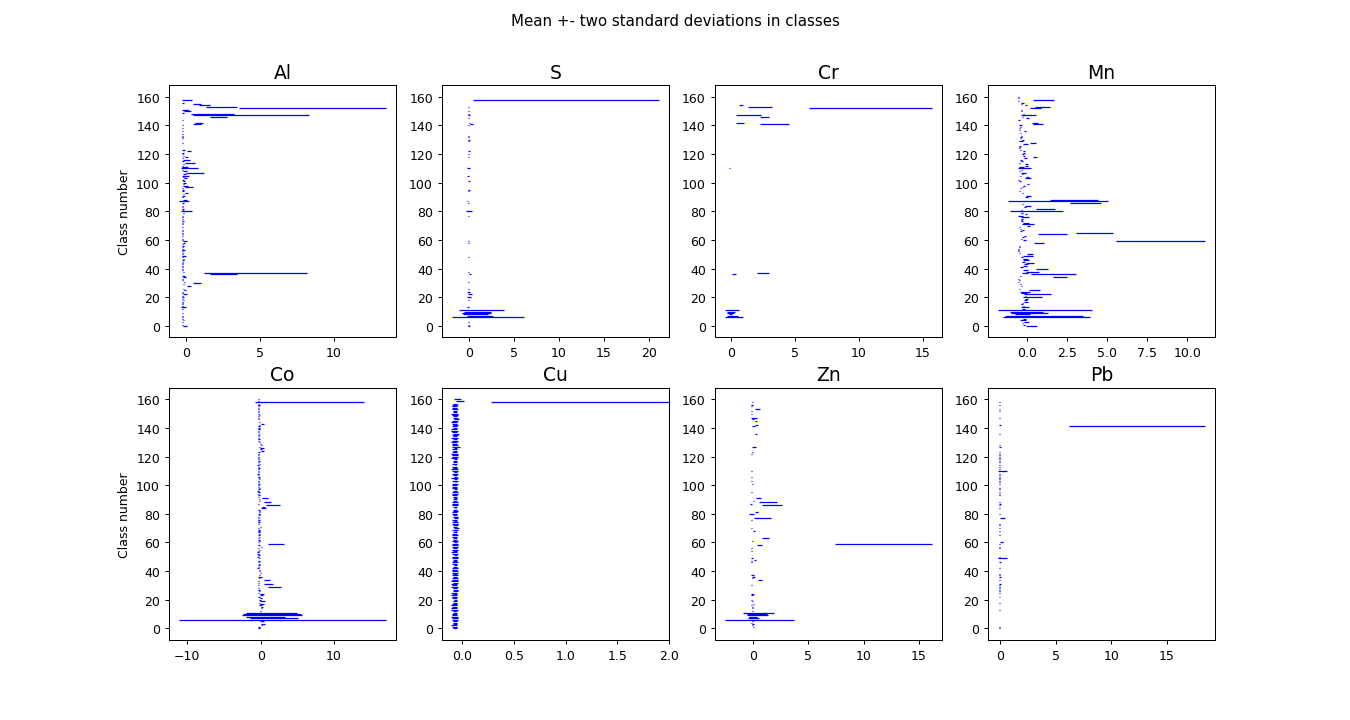

In [111]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

<IPython.core.display.Javascript object>


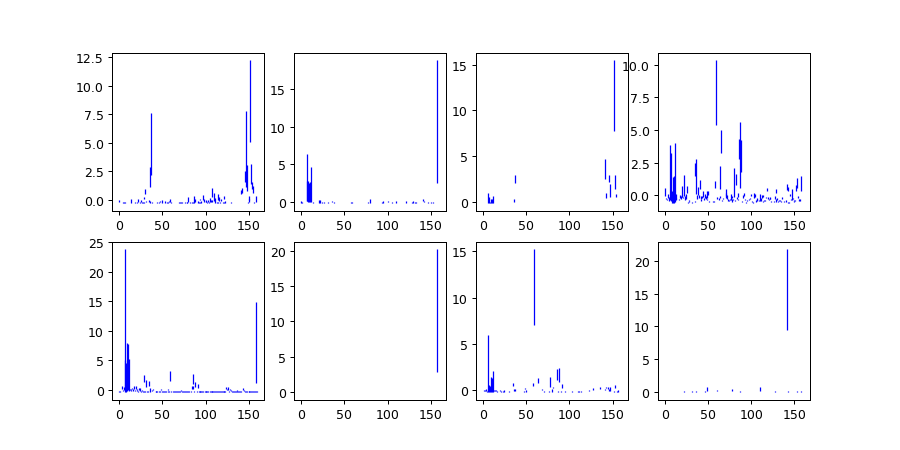

In [104]:
fig, ax = plt.subplots(2,4, figsize=(10,5))
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

<IPython.core.display.Javascript object>


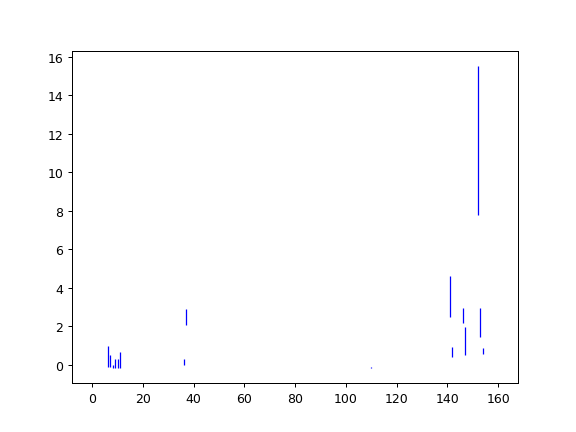

In [108]:
element = 3
for sample_id in range(min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

In [ ]:
inside_min_max_interval = torch.cat([res.unsqueeze(0) for res in res_list])

In [ ]:
(inside_min_max_interval*1.0).mean(axis=0)

In [48]:
(inside_min_max_interval*1.0).mean(axis=0) #best weights: 1/2, 1/4, 1/8, 1/40, ...

tensor([0.2854, 0.3729, 0.0542, 0.0729, 0.0625, 0.0500, 0.0125, 0.2188],
       device='cuda:0')

In [44]:
from_sample.mean(axis=0)

tensor([ 5.0448, -0.1901,  5.1446, -0.1243, -0.5578,  0.0341, -0.1956,  0.1323],
       device='cuda:0')

In [46]:
from_sample.std(axis=0)

tensor([0.7062, 0.0081, 0.2986, 0.0153, 0.0049, 0.0180, 0.0018, 0.0793],
       device='cuda:0')

(array([2., 1., 0., 4., 3., 2., 0., 0., 2., 1.]),
 array([0.0093034 , 0.03666412, 0.06402484, 0.09138557, 0.11874629,
        0.146107  , 0.17346773, 0.20082845, 0.22818917, 0.25554991,
        0.28291062]),
 <BarContainer object of 10 artists>)

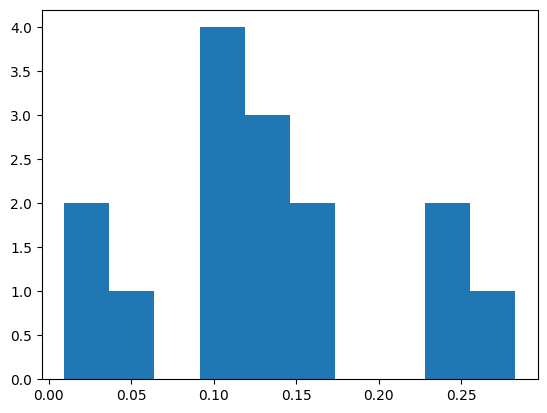

In [67]:
plt.hist(np.array(from_sample[:,7].cpu()))

## Interpretability

...